<a href="https://colab.research.google.com/github/AsimaZaheer/Stress-Detection/blob/main/CNN%2BLSTM%2BLOSO_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] WESAD directory already exists at /content/WESAD.
[INFO] Using device: cpu
  SUBJECT-INDEPENDENT STRESS DETECTION FRAMEWORK
  LOSO Cross-Validation | CNN-BiGRU Hybrid Architecture
  Subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7']

[STEP 1] Preprocessing all selected subjects:
  [SUBJECT S2] Loading raw data...
  [SUBJECT S2] Extracting wrist signals...
  [SUBJECT S2] Synchronizing signals to 4Hz...
  [SUBJECT S2] Creating sliding windows (60s window, 10s step)...
  [SUBJECT S2] Applying baseline calibration (using Label 0 stats)...
  [SUBJECT S2] Done: 212 windows, shape=(212, 240, 2)

  [SUBJECT S3] Loading raw data...
  [SUBJECT S3] Extracting wrist signals...
  [SUBJECT S3] Synchronizing signals to 4Hz...
  [SUBJECT S3] Creating sliding windows (60s window, 10s step)...
  [SUBJECT S3] Applying baseline calibration (using Label 0 stats)...
  [SUBJECT 

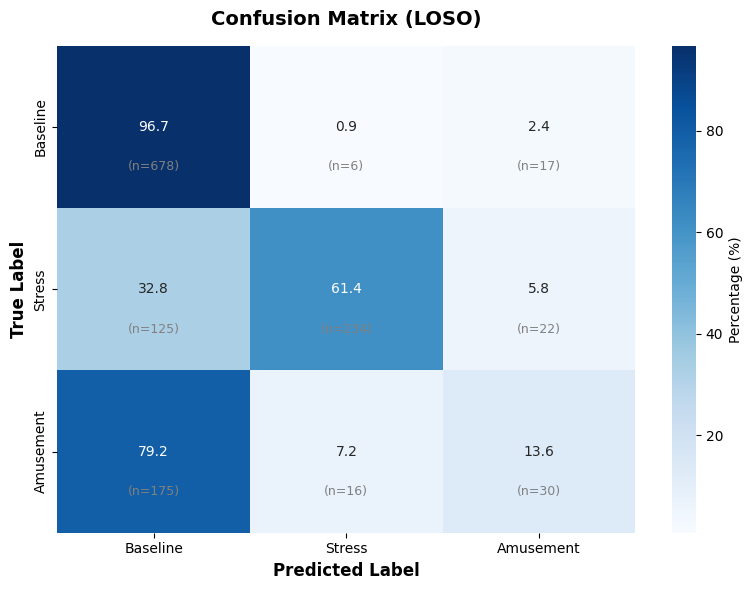


Confusion Matrix (Counts):
           Baseline  Stress  Amusement
Baseline        678       6         17
Stress          125     234         22
Amusement       175      16         30

Confusion Matrix (Row %):
           Baseline  Stress  Amusement
Baseline      96.72    0.86       2.43
Stress        32.81   61.42       5.77
Amusement     79.19    7.24      13.57

  PIPELINE COMPLETE


In [3]:
#!/usr/bin/env python3
"""
Subject-Independent Stress Detection Framework using WESAD Dataset
Leave-One-Subject-Out (LOSO) Cross-Validation with CNN-BiGRU Hybrid Architecture
Designed for Google Colab Environment
"""

# =============================================================================
# 1. GOOGLE DRIVE INTEGRATION & DATASET SETUP
# =============================================================================
import os
import sys
import zipfile

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    WESAD_ZIP = "/content/drive/MyDrive/WESAD.zip"
    WESAD_DIR = "/content/WESAD"

    if not os.path.exists(WESAD_DIR):
        print(f"[INFO] Unzipping WESAD dataset to {WESAD_DIR}...")
        get_ipython().system('unzip -q "{WESAD_ZIP}" -d "/content/"')
        print("[INFO] Unzip completed.")
    else:
        print(f"[INFO] WESAD directory already exists at {WESAD_DIR}.")
else:
    WESAD_DIR = "./WESAD"
    print(f"[WARNING] Not running in Colab. Assuming dataset is at {WESAD_DIR}")

# =============================================================================
# 2. LIBRARY IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import pickle
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.signal import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 3. CONFIGURATION & CONSTANTS
# =============================================================================
SELECTED_SUBJECTS = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7']

TARGET_SR = 4
BVP_ORIG_SR = 64
EDA_ORIG_SR = 4
LABEL_ORIG_SR = 700

WINDOW_SEC = 60
STEP_SEC = 10
WINDOW_SAMPLES = WINDOW_SEC * TARGET_SR
STEP_SAMPLES = STEP_SEC * TARGET_SR

VALID_LABELS_ORIG = [1, 2, 3]
LABEL_MAP = {1: 0, 2: 1, 3: 2}
CLASS_NAMES = ['Baseline', 'Stress', 'Amusement']
NUM_CLASSES = 3

BATCH_SIZE = 64
EPOCHS = 12
LEARNING_RATE = 0.0003
WEIGHT_DECAY = 1e-3
DROPOUT_RATE = 0.4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Using device: {DEVICE}")

# =============================================================================
# 4. DATA LOADING MODULE
# =============================================================================
def load_subject_data(subject_id, wesad_dir):
    """Load raw WESAD subject data from pickle file."""
    pkl_path = os.path.join(wesad_dir, subject_id, f"{subject_id}.pkl")

    if not os.path.exists(pkl_path):
        alt_path = os.path.join(wesad_dir, f"{subject_id}.pkl")
        if os.path.exists(alt_path):
            pkl_path = alt_path
        else:
            raise FileNotFoundError(f"Cannot find pickle for {subject_id} at {pkl_path} or {alt_path}")

    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    return data

def extract_wrist_signals(subject_data):
    """Extract wrist-worn BVP, EDA, and labels from subject data dict."""
    wrist_data = subject_data['signal']['wrist']
    bvp = wrist_data['BVP'].flatten()
    eda = wrist_data['EDA'].flatten()
    labels = subject_data['label'].flatten()
    return bvp, eda, labels

# =============================================================================
# 5. SIGNAL SYNCHRONIZATION & ALIGNMENT
# =============================================================================
def synchronize_signals(bvp, eda, labels):
    """
    Synchronize BVP (64Hz), EDA (4Hz), and Labels (700Hz) to target 4Hz.
    - BVP: scipy.signal.resample from 64Hz -> 4Hz
    - Labels: block-mode majority-vote (mode) decimation, factor = 700/4 = 175 samples/block.
      This eliminates border-shift bleeding caused by linear index stretching.
    Applies symmetric slicing to minimum common length.
    """
    eda_len = len(eda)
    bvp_resampled = resample(bvp, eda_len)

    label_factor = LABEL_ORIG_SR // TARGET_SR
    label_orig_len = len(labels)
    label_target_len = label_orig_len // label_factor
    usable = label_target_len * label_factor
    labels_trimmed = labels[:usable]
    labels_blocks = labels_trimmed.reshape(label_target_len, label_factor)
    labels_block_mode, _ = stats.mode(labels_blocks, axis=1, keepdims=True)
    labels_resampled = labels_block_mode.flatten().astype(labels.dtype)

    min_len = min(len(eda), len(bvp_resampled), len(labels_resampled))
    eda_aligned = eda[:min_len]
    bvp_aligned = bvp_resampled[:min_len]
    labels_aligned = labels_resampled[:min_len]

    return bvp_aligned, eda_aligned, labels_aligned

# =============================================================================
# 6. WINDOWING & LABEL FILTERING
# =============================================================================
def create_sliding_windows(bvp, eda, labels, window_samples=WINDOW_SAMPLES, step_samples=STEP_SAMPLES):
    """
    Create 60s sliding windows with 10s step.
    Returns windowed features and majority labels.
    Filters windows to keep only valid experimental phases.
    """
    n_samples = len(labels)
    windows = []
    window_labels = []

    for start in range(0, n_samples - window_samples + 1, step_samples):
        end = start + window_samples

        label_seg = labels[start:end]
        majority, _ = stats.mode(label_seg, keepdims=True)
        majority = int(majority[0])

        if majority in VALID_LABELS_ORIG:
            bvp_seg = bvp[start:end]
            eda_seg = eda[start:end]
            combined = np.column_stack([eda_seg, bvp_seg])
            windows.append(combined)
            window_labels.append(LABEL_MAP[majority])

    if len(windows) == 0:
        return np.array([]), np.array([])

    return np.array(windows), np.array(window_labels)

# =============================================================================
# 7. SUBJECT-WISE BASELINE CALIBRATION
# =============================================================================
def subject_baseline_calibration(windows, labels):
    """
    Standardize each subject's data using their own Baseline (Label 0) phase statistics.
    Computes mean/std from baseline windows and z-scores all windows.
    """
    if len(windows) == 0:
        return windows

    baseline_mask = labels == 0

    if not np.any(baseline_mask):
        print("[WARNING] No baseline windows found for subject calibration. Skipping.")
        return windows

    baseline_windows = windows[baseline_mask]
    baseline_combined = baseline_windows.reshape(-1, baseline_windows.shape[-1])

    mean = baseline_combined.mean(axis=0)
    std = baseline_combined.std(axis=0)
    std[std == 0] = 1e-8

    calibrated = np.zeros_like(windows)
    for i in range(len(windows)):
        calibrated[i] = (windows[i] - mean) / std

    return calibrated

# =============================================================================
# 8. DATASET PREPARATION PIPELINE
# =============================================================================
def prepare_subject_dataset(subject_id, wesad_dir):
    """
    Full pipeline: load -> extract -> sync -> window -> baseline calibrate.
    Returns processed windows and labels for one subject.
    """
    print(f"  [SUBJECT {subject_id}] Loading raw data...")
    raw_data = load_subject_data(subject_id, wesad_dir)

    print(f"  [SUBJECT {subject_id}] Extracting wrist signals...")
    bvp, eda, labels = extract_wrist_signals(raw_data)

    print(f"  [SUBJECT {subject_id}] Synchronizing signals to {TARGET_SR}Hz...")
    bvp_aligned, eda_aligned, labels_aligned = synchronize_signals(bvp, eda, labels)

    print(f"  [SUBJECT {subject_id}] Creating sliding windows ({WINDOW_SEC}s window, {STEP_SEC}s step)...")
    windows, window_labels = create_sliding_windows(bvp_aligned, eda_aligned, labels_aligned)

    if len(windows) == 0:
        print(f"  [WARNING] SUBJECT {subject_id}: No valid windows after filtering.")
        return np.array([]), np.array([])

    print(f"  [SUBJECT {subject_id}] Applying baseline calibration (using Label 0 stats)...")
    calibrated_windows = subject_baseline_calibration(windows, window_labels)

    print(f"  [SUBJECT {subject_id}] Done: {len(calibrated_windows)} windows, "
          f"shape={calibrated_windows.shape}")
    return calibrated_windows, window_labels

# =============================================================================
# 9. CNN-BiGRU HYBRID MODEL ARCHITECTURE
# =============================================================================
class CNNBiGRU(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE):
        super(CNNBiGRU, self).__init__()

        spatial_dropout = dropout_rate
        temporal_dropout = dropout_rate
        classifier_dropout = dropout_rate

        in_channels = 2
        cnn_out_channels_1 = 32
        cnn_out_channels_2 = 64
        kernel_size = 3
        pool_size = 2
        gru_hidden = 128
        gru_layers = 2

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, cnn_out_channels_1, kernel_size=kernel_size, padding=1),
            nn.BatchNorm1d(cnn_out_channels_1),
            nn.ReLU(),
            nn.MaxPool1d(pool_size),

            nn.Conv1d(cnn_out_channels_1, cnn_out_channels_2, kernel_size=kernel_size, padding=1),
            nn.BatchNorm1d(cnn_out_channels_2),
            nn.ReLU(),
            nn.MaxPool1d(pool_size),

            nn.Dropout(spatial_dropout),
        )

        with torch.no_grad():
            dummy = torch.randn(1, in_channels, WINDOW_SAMPLES)
            cnn_out = self.cnn(dummy)
            self.gru_input_size = cnn_out.shape[1]
            self.gru_seq_len = cnn_out.shape[2]

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=temporal_dropout,
        )

        classifier_input = gru_hidden * 2
        self.classifier = nn.Sequential(
            nn.Linear(classifier_input, classifier_input // 2),
            nn.ReLU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(classifier_input // 2, num_classes),
        )

    def forward(self, x):
        batch_size = x.size(0)

        x = x.permute(0, 2, 1)
        x = self.cnn(x)

        x = x.permute(0, 2, 1)
        gru_out, _ = self.bigru(x)

        pooled = gru_out.mean(dim=1)

        logits = self.classifier(pooled)
        return logits

# =============================================================================
# 10. LOSO CROSS-VALIDATION ENGINE
# =============================================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_true = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device).float()
        y_batch = y_batch.to(device).long()

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_preds)
    return avg_loss, acc

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_true = []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device).long()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.cpu().numpy())
            all_probs.extend(probs)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_preds)
    return avg_loss, acc, np.array(all_true), np.array(all_preds), np.array(all_probs)

def run_loso_fold(subject_data_dict, test_subject_id):
    """
    Run one LOSO fold:
    - Isolate test subject
    - Fit scaler on combined training subjects
    - Apply transform independently
    - Dynamic inverse-frequency class weighting for imbalanced classes
    - Best snapshot tracking by val accuracy (not final epoch)
    """
    print(f"\n{'='*70}")
    print(f"[FOLD] Test Subject: {test_subject_id}")
    print(f"{'='*70}")

    train_subjects = [s for s in SELECTED_SUBJECTS if s != test_subject_id]

    X_train_list = []
    y_train_list = []
    for s in train_subjects:
        X_s, y_s = subject_data_dict[s]
        if len(X_s) > 0:
            X_train_list.append(X_s)
            y_train_list.append(y_s)

    X_train_raw = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)

    X_test_raw, y_test = subject_data_dict[test_subject_id]
    if len(X_test_raw) == 0:
        print(f"[FOLD] No windows for test subject {test_subject_id}. Skipping.")
        return None, None

    n_train, seq_len, n_feat = X_train_raw.shape
    scaler = StandardScaler()
    X_train_flat = X_train_raw.reshape(-1, n_feat)
    scaler.fit(X_train_flat)

    X_train_scaled = scaler.transform(X_train_flat).reshape(n_train, seq_len, n_feat)

    n_test = X_test_raw.shape[0]
    X_test_flat = X_test_raw.reshape(-1, n_feat)
    X_test_scaled = scaler.transform(X_test_flat).reshape(n_test, seq_len, n_feat)

    print(f"  Train set: {X_train_scaled.shape[0]} windows | "
          f"Test set: {X_test_scaled.shape[0]} windows")
    print(f"  Train class dist: {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"  Test class dist: {dict(zip(*np.unique(y_test, return_counts=True)))}")

    train_classes, train_counts = np.unique(y_train, return_counts=True)
    total_samples = len(y_train)
    class_weights = np.ones(NUM_CLASSES, dtype=np.float32)
    for cls_idx in range(NUM_CLASSES):
        if cls_idx in train_classes:
            count_c = train_counts[train_classes == cls_idx][0]
            class_weights[cls_idx] = total_samples / (NUM_CLASSES * count_c)
    class_weights = class_weights * 2.5
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    print(f"  Dynamic class weights (×2.5 boosted): {dict(zip(CLASS_NAMES, np.round(class_weights, 4)))}")

    train_ds = TensorDataset(torch.from_numpy(X_train_scaled), torch.from_numpy(y_train))
    test_ds = TensorDataset(torch.from_numpy(X_test_scaled), torch.from_numpy(y_test))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    torch.manual_seed(42)
    model = CNNBiGRU().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_val_acc = 0.0
    best_y_true = np.array([])
    best_y_pred = np.array([])
    best_epoch = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, y_true_fold_epoch, y_pred_fold_epoch, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        improved_marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_y_true = y_true_fold_epoch.copy()
            best_y_pred = y_pred_fold_epoch.copy()
            best_epoch = epoch
            improved_marker = "  <-- BEST SNAPSHOT"

        print(f"  Epoch [{epoch}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Test Loss: {val_loss:.4f} Acc: {val_acc:.4f}{improved_marker}")

    print(f"\n  [FOLD RESULT] Subject {test_subject_id} | "
          f"Best Epoch: {best_epoch}/{EPOCHS} | "
          f"Best Accuracy: {best_val_acc:.4f}")

    return best_y_true, best_y_pred

# =============================================================================
# 11. EVALUATION & VISUALIZATION
# =============================================================================
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix (LOSO)"):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage (%)'}, ax=ax)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            ax.text(j + 0.5, i + 0.7, f'\n(n={count})',
                    ha='center', va='center', color='gray', fontsize=9)

    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

    return cm, cm_percent

# =============================================================================
# 12. MAIN EXECUTION PIPELINE
# =============================================================================
def main():
    print("=" * 70)
    print("  SUBJECT-INDEPENDENT STRESS DETECTION FRAMEWORK")
    print("  LOSO Cross-Validation | CNN-BiGRU Hybrid Architecture")
    print("  Subjects:", SELECTED_SUBJECTS)
    print("=" * 70)

    if not os.path.exists(WESAD_DIR):
        print(f"[ERROR] WESAD directory not found at {WESAD_DIR}")
        print("  Please mount Google Drive and ensure WESAD.zip is at '/content/drive/MyDrive/WESAD.zip'")
        return

    subject_data_dict = {}
    print("\n[STEP 1] Preprocessing all selected subjects:")
    for subj in SELECTED_SUBJECTS:
        X, y = prepare_subject_dataset(subj, WESAD_DIR)
        subject_data_dict[subj] = (X, y)
        print()

    valid_subjects = [s for s in SELECTED_SUBJECTS if len(subject_data_dict[s][0]) > 0]
    if len(valid_subjects) < 2:
        print("[ERROR] Not enough valid subjects with data.")
        return

    print("\n[STEP 2] Running Leave-One-Subject-Out Cross-Validation:")
    all_y_true = []
    all_y_pred = []
    fold_accuracies = {}

    for test_subj in valid_subjects:
        y_true_fold, y_pred_fold = run_loso_fold(subject_data_dict, test_subj)
        if y_true_fold is not None:
            all_y_true.extend(y_true_fold)
            all_y_pred.extend(y_pred_fold)
            fold_accuracies[test_subj] = accuracy_score(y_true_fold, y_pred_fold)

    print(f"\n{'='*70}")
    print("  LOSO CROSS-VALIDATION - FINAL RESULTS")
    print(f"{'='*70}")

    print("\nPer-Subject Holdout Accuracies:")
    for subj, acc in fold_accuracies.items():
        print(f"  Subject {subj}: {acc:.4f} ({acc*100:.2f}%)")

    overall_acc = accuracy_score(all_y_true, all_y_pred)
    print(f"\nOverall LOSO Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
    print(f"Mean Per-Subject Accuracy: {np.mean(list(fold_accuracies.values())):.4f} "
          f"(±{np.std(list(fold_accuracies.values())):.4f})")

    print(f"\n{'='*70}")
    print("  CLASSIFICATION REPORT")
    print(f"{'='*70}")
    report = classification_report(
        all_y_true, all_y_pred,
        target_names=CLASS_NAMES,
        digits=4,
    )
    print(report)

    print(f"\n{'='*70}")
    print("  CONFUSION MATRIX")
    print(f"{'='*70}")
    cm, cm_pct = plot_confusion_matrix(np.array(all_y_true), np.array(all_y_pred), CLASS_NAMES)

    print("\nConfusion Matrix (Counts):")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    print("\nConfusion Matrix (Row %):")
    print(pd.DataFrame(np.round(cm_pct, 2), index=CLASS_NAMES, columns=CLASS_NAMES))

    print("\n" + "=" * 70)
    print("  PIPELINE COMPLETE")
    print("=" * 70)

    return {
        'fold_accuracies': fold_accuracies,
        'overall_accuracy': overall_acc,
        'classification_report': report,
        'confusion_matrix': cm,
        'y_true': all_y_true,
        'y_pred': all_y_pred,
    }


if __name__ == "__main__":
    results = main()
